In [26]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib

In [28]:
df = pd.read_csv("data/House Price Prediction.csv")
print(df.shape)
df.head()


(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

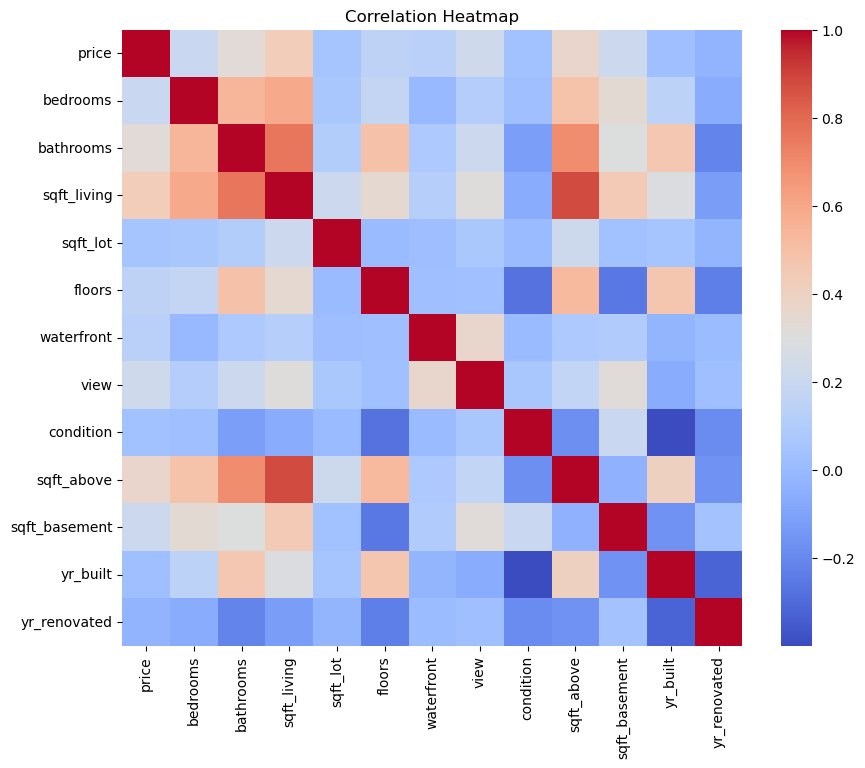

In [30]:
# 3. Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [31]:

# 4. Handle missing values
df = df.fillna(df.median(numeric_only=True))

In [34]:

# 5. Feature Engineering
numeric_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [36]:
# 1. Define target column
target_col = "price"

# 2. Features (X) and target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# 3. Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Confirm shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (3680, 17)
X_test shape: (920, 17)
y_train shape: (3680,)
y_test shape: (920,)


In [38]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# 1. Target column
target_col = "price"

# 2. Split features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Define feature groups (only features, NOT target)
numeric_features = [
    'bedrooms','bathrooms','sqft_living','sqft_lot',
    'floors','sqft_above','sqft_basement','yr_built','yr_renovated'
]

categorical_features = [
    'waterfront','view','condition','street','city','statezip','country'
]

# 5. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'   # drop columns not listed above (like 'date')
)

# 6. Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# 7. Train and evaluate
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{name} RMSE: {rmse:.2f}")


Linear Regression RMSE: 2191254.70



KeyboardInterrupt



In [45]:
# 8. Save Best Model (Gradient Boosting chosen here)
best_model = Pipeline([('preprocessor', preprocessor),
                       ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
best_model.fit(X_train, y_train)
joblib.dump(best_model, "house_price_model.pkl")

['house_price_model.pkl']

In [46]:

# 9. Load model and predict on a sample
loaded_model = joblib.load("house_price_model.pkl")
sample = X_test.iloc[0:1]
print("\nSample input:\n", sample)
print("Predicted price:", loaded_model.predict(sample))


Sample input:
                      date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
3683  2014-06-30 00:00:00       3.0        2.5         1460      1613     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
3683           0     0          3        1180            280      2007   

      yr_renovated              street     city  statezip country  
3683             0  6710 Alonzo Ave NW  Seattle  WA 98117     USA  
Predicted price: [422583.45276944]


In [47]:
import os
print(os.getcwd())


C:\Users\G.HEMNATH\Documents\house-price-prediction


In [48]:

print(os.listdir("data"))


['.ipynb_checkpoints', 'House Price Prediction.csv']


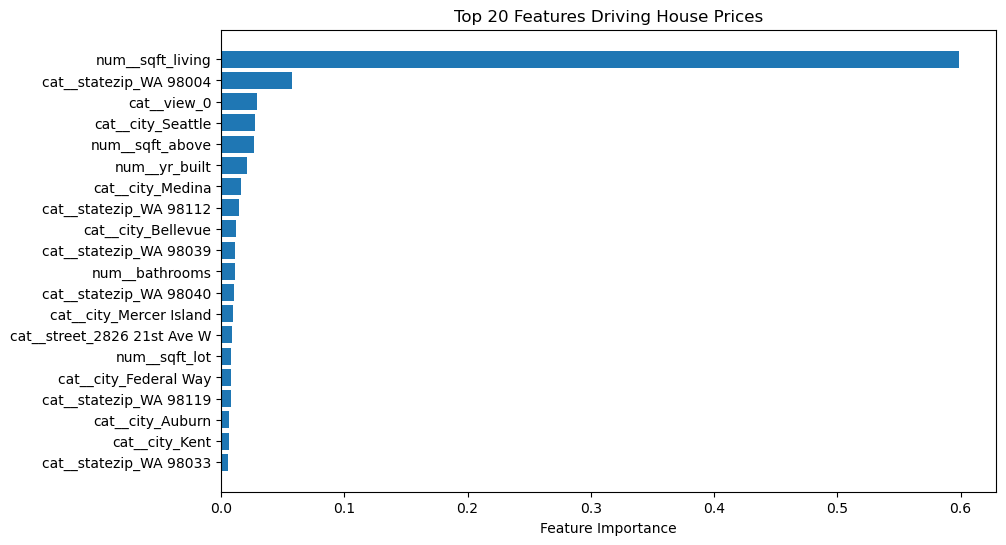

In [49]:




import matplotlib.pyplot as plt

# Use the saved model if it's a tree-based one
model = loaded_model.named_steps['model']
feature_names = loaded_model.named_steps['preprocessor'].get_feature_names_out()

importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features Driving House Prices")
plt.show()



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.savefig("screenshots/correlation_heatmap.png")  # creates file in screenshots folder
plt.show()


NameError: name 'df' is not defined

<Figure size 1000x800 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Prediction Example")

plt.savefig("screenshots/prediction_example.png")
plt.show()



In [ ]:
importances = best_model.feature_importances_

plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")

plt.savefig("screenshots/feature_importance.png")
plt.show()
